In [3]:
# Importing the necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **CFPB Dataset Loading, Preprocessing, Feature Engineering, and Stratified Sampling**

Objective: Prepare the CFPB complaints dataset for downstream analysis by engineering temporal and geographic fields, conducting product-level diagnostics, and producing a modeling-ready Credit Card subset.

This notebook emphasizes:
- full-dataset context checks and quality diagnostics
- feature engineering (`year_quarter`, `region`, `stratum`)
- quarterly Credit Reporting trend diagnostics
- construction/export of a trimmed Credit Card analysis subset

This notebook produces the following artifacts:
- engineered temporal and geographic features on the raw complaints data
- product/time/region diagnostics for exploratory comparison
- Credit Reporting monthly and quarterly trend support tables for downstream notebooks
- final trimmed Credit Card subset for EDA and forecasting workflows

# **1. Project Context**

## 1.1 Background

Consumer complaints provide a real-time signal of stress across financial products and geographies. The CFPB complaint database enables longitudinal analysis of product dynamics, seasonal patterns, and regional differences in complaint burden.

## 1.2 Research Questions

This project addresses the following questions:

- **RQ1: Do Southern-region complaint trajectories exhibit meaningfully different temporal dynamics (trend, seasonality, volatility) versus non-Southern regions?**
- **RQ2: Which model families produce the most actionable forecasts for regional credit reporting complaints?**
- **RQ3: Are credit reporting complaints expected to continue rising through 2027, and at what relative pace across regions?**

## 1.3 Relevance and Practical Implications

Potential implications include:

(i) For CFPB:
- Resource allocation for investigations and supervisory capacity
- Better staffing/budget planning with monthly or quarterly lead indicators
- Regional equity monitoring and targeted interventions

(ii) For Financial Institutions:
- Proactive customer service and compliance capacity planning
- Earlier risk detection in high-growth complaint segments
- Better regulator engagement using forward-looking metrics

(iii) For Consumers and Advocates:
- Greater transparency on complaint pressure and expected responsiveness
- Better evidence for regional protection advocacy

## 1.4 Limitations

- Forecasts describe expected trajectory, not root-cause mechanisms.
- Exogenous shocks (policy shifts, breaches, macro events) may break historical patterns.
- Product categories can embed heterogeneous sub-issue behavior.
- Current scope prioritizes South vs. non-South over state-level modeling.

# **2. Data Description**

## 2.1 Dataset Overview

The [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/) is a public source containing over 13.8 million complaints (2011 to present, through February 2026 for this project). It spans major financial domains including credit reporting, credit cards, debt collection, mortgages, and banking.

Core fields include complaint timing, product/sub-product, issue taxonomy, company metadata, state geography, and response attributes. These fields support trend analysis, product comparison, regional diagnostics, and downstream forecasting.

## 2.2 Dataset Characteristics

- Source: Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database
- Access: Publicly available at https://www.consumerfinance.gov/data-research/consumer-complaints/
- Scope: Historical complaints from July 2011 through the project extract date (February 24, 2026)
- Size at extract: 13.8M+ records (raw CSV > 4.9 GB)
- Project repository: https://github.com/kazishahid-ds/CFPB-complaints-analysis

# **3. Exploratory Data Analysis (EDA) #1 - Full Dataset EDA**

This section establishes high-level context from the full dataset before filtering or modeling-specific transformations.

The EDA answers four questions:
- How large is the raw dataset and what fields are available?
- Which columns have the highest missingness?
- Which product categories dominate complaint volume?
- How do volume and submission channels evolve over time?

In [4]:
# Loading the full dataset
df = pd.read_csv(r"..\data\complaints.csv")

In [4]:
# Display the shape and column names of the loaded dataset
print(f"The loaded dataset has {df.shape[0]:,} rows, and {df.shape[1]:,} columns as follows:\n{df.columns.tolist()}")

The loaded dataset has 13,843,560 rows, and 18 columns as follows:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [5]:
# Preview core fields from the full dataset
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-13,Mortgage,FHA mortgage,Trouble during payment process,NaN,"I currently have my mortgage with GMFS, servic...",NaN,"SAMC Honebee TRS, LLC",AL,36695,NaN,Consent provided,Web,2020-07-13,Closed with explanation,Yes,NaN,3743391
1,2023-12-16,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"FactorTrust, Inc.",NY,13224,NaN,Consent not provided,Web,2023-12-16,Closed with explanation,Yes,NaN,8011171
2,2024-01-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,11714,NaN,Consent not provided,Web,2024-01-27,Closed with non-monetary relief,Yes,NaN,8236394
3,2019-05-22,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with fraud alerts or security freezes,NaN,Have had a couple years of problems getting an...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CA,95628,Older American,Consent provided,Web,2019-05-22,Closed with explanation,Yes,NaN,3251015
4,2023-12-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32703,NaN,Consent not provided,Web,2023-12-21,Closed with explanation,Yes,NaN,8032795


In [5]:
# Ensure Date received is datetime for time-based summaries/plots
if not pd.api.types.is_datetime64_any_dtype(df["Date received"]):
    df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")

In [7]:
# Summarize the size, coverage, and cardinality of the raw dataset
dataset_overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Date coverage start",
            "Date coverage end",
            "Unique products",
            "Unique sub-products",
            "Unique companies",
            "Unique states",
            "In-memory size (GB)",
        ],
        "value": [
            f"{len(df):,}",
            df.shape[1],
            df["Date received"].min().date(),
            df["Date received"].max().date(),
            df["Product"].nunique(dropna=True),
            df["Sub-product"].nunique(dropna=True),
            df["Company"].nunique(dropna=True),
            df["State"].nunique(dropna=True),
            round(df.memory_usage(deep=True).sum() / 1024**3, 2),
        ],
    }
)

print("Key characteristics of the dataset:")
dataset_overview

Key characteristics of the dataset:


,metric,value
0,Rows,"13,843,560"
1,Columns,18
2,Date coverage start,2011-12-01
3,Date coverage end,2026-02-24
4,Unique products,21
5,Unique sub-products,86
6,Unique companies,7833
7,Unique states,63
8,In-memory size (GB),18.03


In [6]:
# Cut off date coverage end to the last full-month data (i.e., month ending 31 January 2026)
cutoff_date_start = pd.to_datetime("2012-01-01")
cutoff_date_end = pd.to_datetime("2025-12-31")
df = df[(df["Date received"] >= cutoff_date_start) & (df["Date received"] <= cutoff_date_end)]

print(f"The dataset's coverage end date is now bounded within {cutoff_date_start.date()} and {cutoff_date_end.date()} to ensure we only analyze complete quarters of data.")

The dataset's coverage end date is now bounded within 2012-01-01 and 2025-12-31 to ensure we only analyze complete quarters of data.


In [9]:
# Inspect missingness across the full-dataset fields used in this notebook
missingness_summary = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
      .rename_axis("column")
      .reset_index(name="missing_pct")
      .sort_values(["missing_pct", "column"], ascending=[False, True])
      .reset_index(drop=True)
)

print("Missingness summary for key fields:")
missingness_summary

Missingness summary for key fields:


,column,missing_pct
0,Tags,94.55
1,Consumer disputed?,94.03
2,Consumer complaint narrative,70.98
3,Company public response,44.91
4,Consumer consent provided?,10.81
5,Sub-issue,6.83
6,Sub-product,1.82
7,State,0.46
8,ZIP code,0.24
9,Company,0.00


,product,complaint_count
11,Credit reporting or other personal consumer re...,7729028
10,"Credit reporting, credit repair services, or o...",2163844
9,Debt collection,969211
8,Mortgage,435553
7,Checking or savings account,334214
6,Credit card,276431
5,Credit card or prepaid card,206368
4,"Money transfer, virtual currency, or money ser...",164849
3,Credit reporting,140429
2,Student loan,119047


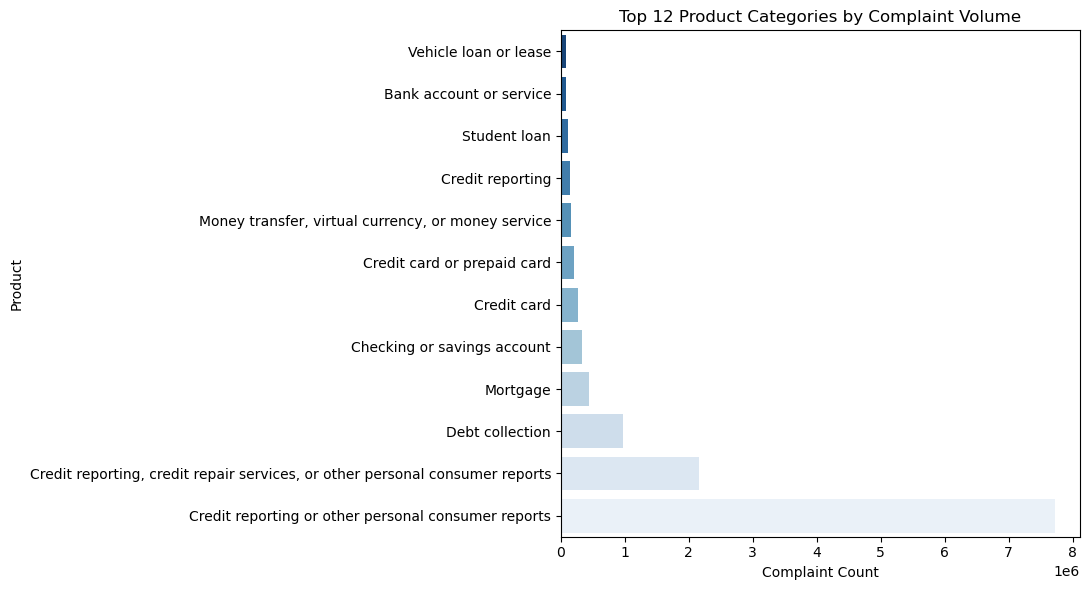

In [10]:
# Visualize the dominant complaint products in the full dataset
product_counts = (
    df["Product"]
      .fillna("Missing")
      .value_counts()
      .head(12)
      .sort_values()
      .rename_axis("product")
      .reset_index(name="complaint_count")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=product_counts,
    x="complaint_count",
    y="product",
    palette="Blues_r",
    ax=ax,
    hue="product",
    legend=False,
 )
ax.set_title("Top 12 Product Categories by Complaint Volume")
ax.set_xlabel("Complaint Count")
ax.set_ylabel("Product")
plt.tight_layout()

product_counts.sort_values("complaint_count", ascending=False)

,submitted_via,complaint_count
6,Web,12224714
5,Referral,267517
4,Phone,209507
3,Postal mail,106634
2,Fax,25647
1,Web Referral,1240
0,Email,414


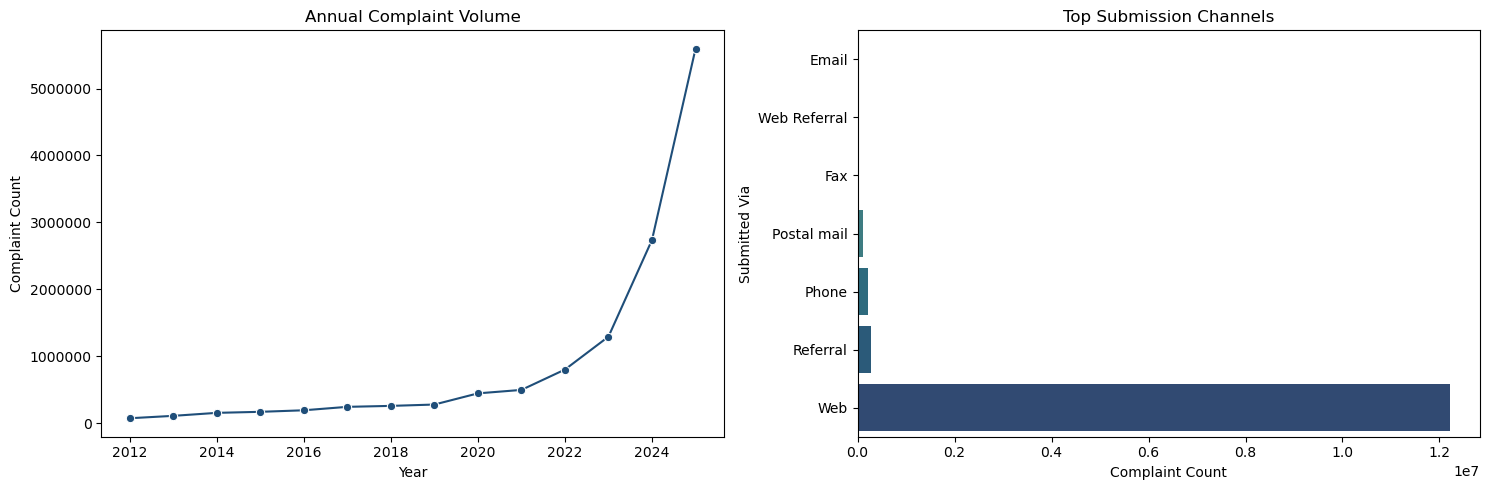

In [11]:
# Plot overall complaint volume through time and summarize submission channels
yearly_counts = (
    df.assign(year=df["Date received"].dt.year)
      .groupby("year")
      .size()
      .reset_index(name="complaint_count")
)

submission_counts = (
    df["Submitted via"]
      .fillna("Missing")
      .value_counts()
      .head(8)
      .sort_values()
      .rename_axis("submitted_via")
      .reset_index(name="complaint_count")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=yearly_counts,
    x="year",
    y="complaint_count",
    marker="o",
    color="#1f4e79",
    ax=axes[0],
)
axes[0].set_title("Annual Complaint Volume")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Complaint Count")
axes[0].ticklabel_format(style="plain", axis="y")

sns.barplot(
    data=submission_counts,
    x="complaint_count",
    y="submitted_via",
    palette="crest",
    ax=axes[1],
    hue="submitted_via",
    legend=False,
 )
axes[1].set_title("Top Submission Channels")
axes[1].set_xlabel("Complaint Count")
axes[1].set_ylabel("Submitted Via")

plt.tight_layout()

submission_counts.sort_values("complaint_count", ascending=False)

# **4. Feature Engineering**

This section builds reusable features that support temporal aggregation, regional comparison, and stratified analyses used in downstream notebooks.

## 4.1 Create Year-Quarter

The complaint date field is converted into quarter labels to support consistent trend analysis and seasonal comparison at quarter granularity.

In [7]:
# Create a year-quarter feature for time-based analyses
df['year_quarter'] = (
    df['Date received']
      .dt.to_period('Q')
      .astype(str)
)

This transformation produces quarterly labels such as `2021Q1`, `2022Q3`, etc.

## 4.2 Map State to Region

This step will ensure that the workflow uses U.S. Census-style regional groupings rather than individual states. This reduces sparsity while preserving interpretable geographic structure for downstream analysis.

**1. Northeast**
- CT, ME, MA, NH, RI, VT
- NJ, NY, PA

**2. Midwest**
- IL, IN, MI, OH, WI
- IA, KS, MN, MO, NE, ND, SD

**3. South**
- DE, FL, GA, MD, NC, SC, VA, DC, WV
- AL, KY, MS, TN
- AR, LA, OK, TX

**4. West**
- AZ, CO, ID, MT, NV, NM, UT, WY
- AK, CA, HI, OR, WA

**5. Other**
- Remaining values in `State` (for example territories or non-state codes)

In [10]:
# Map states to US regions for geographic analyses
northeast = ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']
midwest   = ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']
south     = ['DE','FL','GA','MD','NC','SC','VA','DC','WV',
             'AL','KY','MS','TN','AR','LA','OK','TX']
west      = ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']

def map_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

df['region'] = df['State'].apply(map_region)

Regional share is reviewed here to confirm that the aggregated geography feature is coherent and suitable for proportional sampling.

In [14]:
# Display the distribution of complaints across regions to check for any anomalies or dominant regions
print(f"Proportion of complaints by region:\n{df['region'].value_counts(normalize=True).apply(lambda x: f'{x:.2%}')}")

Proportion of complaints by region:
region
South        53.64%
West         16.26%
Northeast    16.04%
Midwest      13.17%
Other         0.89%
Name: proportion, dtype: object


# **5. EDA #2 - Product-Level EDA**

## 5.1 EDA of All Products

This section profiles product-level complaint dynamics using the engineered quarter feature. It provides context for selecting focused product tracks used in later notebooks.

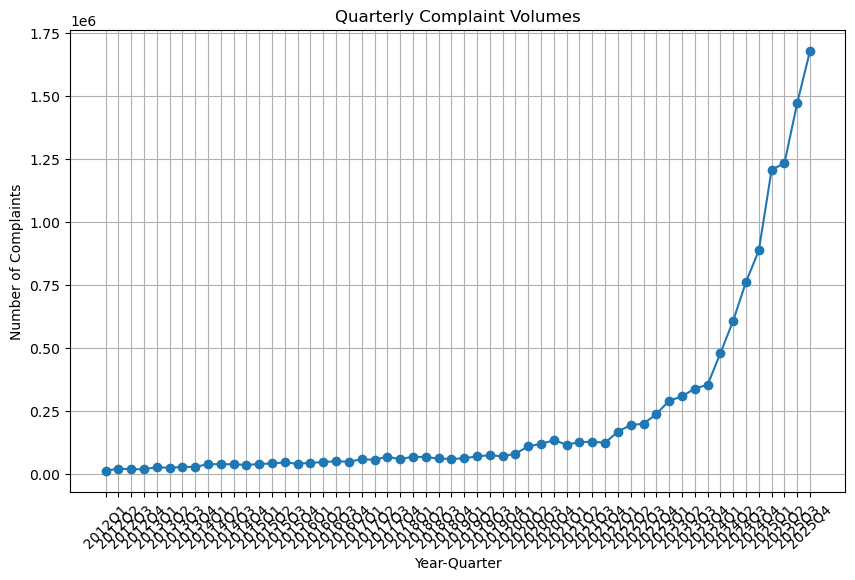

In [15]:
# Generate total number of complaints for each quarter
quarterly_complaints = df.groupby('year_quarter').size().reset_index(name='num_complaints')

# Plot the quarterly complaint volumes
plt.figure(figsize=(10, 6))
plt.plot(quarterly_complaints['year_quarter'], quarterly_complaints['num_complaints'], marker='o')
plt.title('Quarterly Complaint Volumes')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

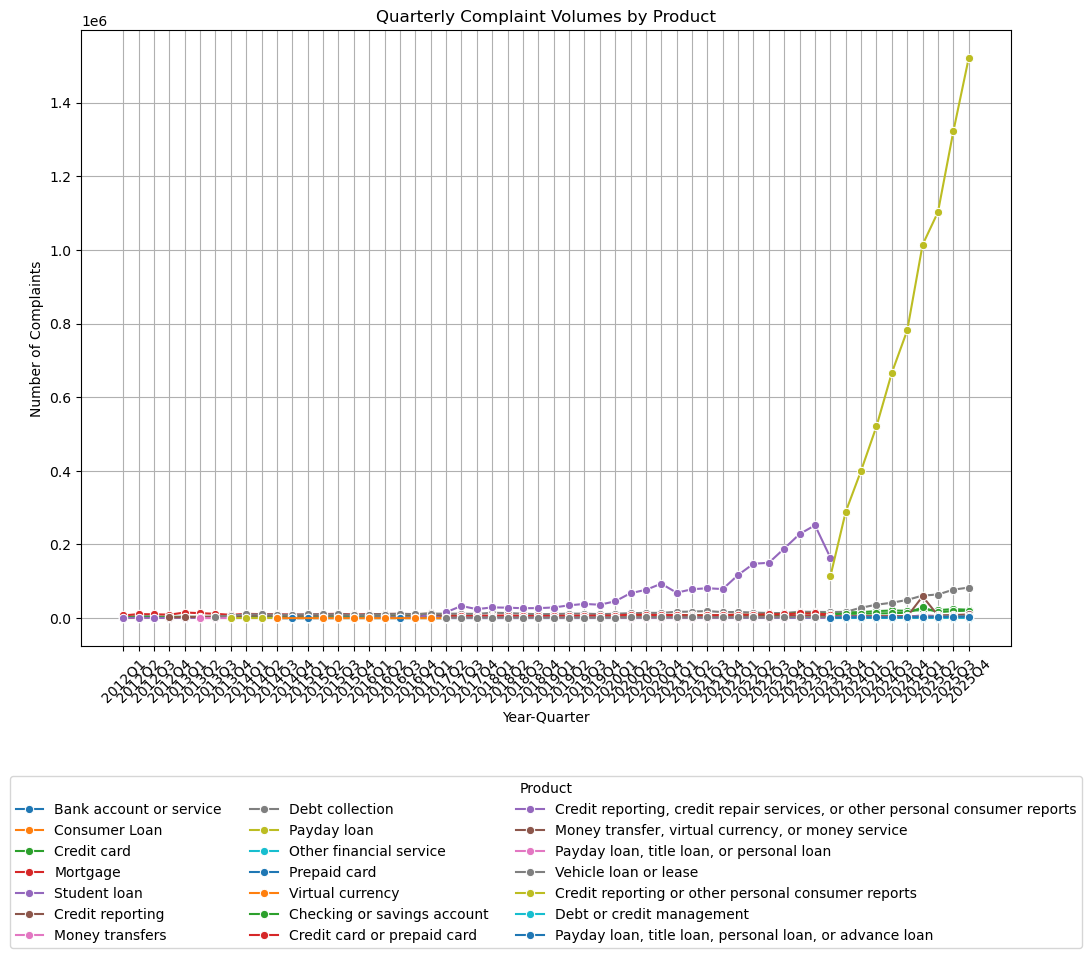

In [16]:
# Create the distribution of complaints by product per quarter
product_counts_qtr = df.groupby(['year_quarter', 'Product']).size().reset_index(name='num_complaints')

# Plot the distribution of complaints by product per quarter
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=product_counts_qtr,
    x='year_quarter',
    y='num_complaints',
    hue='Product',
    marker='o',
    palette='tab10'
)
plt.title('Quarterly Complaint Volumes by Product')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.legend(title='Product', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=True)
plt.grid(True)
#plt.tight_layout()
plt.show()

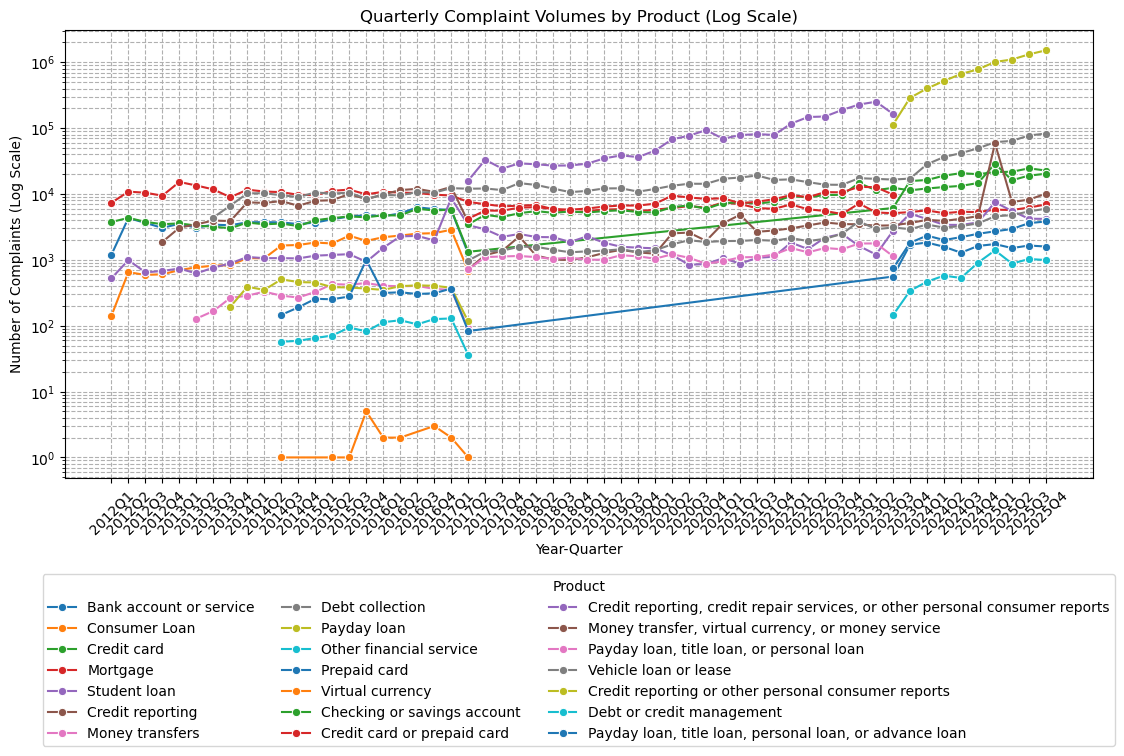

In [17]:
# Plotting a log-transformed product_counts_qtr to better visualize trends for less common products
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=product_counts_qtr,
    x='year_quarter',
    y='num_complaints',
    hue='Product',
    marker='o',
    palette='tab10'
)
plt.title('Quarterly Complaint Volumes by Product (Log Scale)')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints (Log Scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.legend(title='Product', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=True)
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

In [18]:
# Tabulate the complaint counts by product and quarter (year_quarter in col. 1, and then each product takes a column each)
product_counts_pivot = product_counts_qtr.pivot(index='year_quarter', columns='Product', values='num_complaints').fillna(0)
product_counts_pivot

Product,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Debt or credit management,...,Money transfers,Mortgage,Other financial service,Payday loan,"Payday loan, title loan, or personal loan","Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease,Virtual currency
year_quarter,,,,,,,,,,,,,,,,,,,,,
2012Q1,1191.0,0.0,141.0,3757.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7356.0,0.0,0.0,0.0,0.0,0.0,524.0,0.0,0.0
2012Q2,4318.0,0.0,650.0,4340.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10860.0,0.0,0.0,0.0,0.0,0.0,992.0,0.0,0.0
2012Q3,3643.0,0.0,591.0,3780.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10465.0,0.0,0.0,0.0,0.0,0.0,646.0,0.0,0.0
2012Q4,3060.0,0.0,604.0,3476.0,0.0,1873.0,0.0,0.0,0.0,0.0,...,0.0,9427.0,0.0,0.0,0.0,0.0,0.0,678.0,0.0,0.0
2013Q1,3532.0,0.0,698.0,3584.0,0.0,3074.0,0.0,0.0,0.0,0.0,...,0.0,15247.0,0.0,0.0,0.0,0.0,0.0,739.0,0.0,0.0
2013Q2,3077.0,0.0,771.0,3310.0,0.0,3470.0,0.0,0.0,0.0,0.0,...,128.0,13459.0,0.0,0.0,0.0,0.0,0.0,622.0,0.0,0.0
2013Q3,3428.0,0.0,815.0,3197.0,0.0,3949.0,0.0,0.0,4397.0,0.0,...,167.0,11756.0,0.0,0.0,0.0,0.0,0.0,762.0,0.0,0.0
2013Q4,3351.0,0.0,833.0,3014.0,0.0,3887.0,0.0,0.0,6672.0,0.0,...,264.0,8936.0,0.0,194.0,0.0,0.0,0.0,882.0,0.0,0.0
2014Q1,3723.0,0.0,1063.0,3690.0,0.0,7484.0,0.0,0.0,10228.0,0.0,...,286.0,11637.0,0.0,390.0,0.0,0.0,0.0,1106.0,0.0,0.0


The three historical Credit Reporting product labels represent the same product family across different periods. To avoid fragmented trends, the labels are consolidated into a single normalized `Credit reporting` category before downstream diagnostics and exports. Same was done for Payday loan and Money transfer products.

In [ ]:
# Normalize product labels to reduce category fragmentation before export
# Collapse all labels that start with "Credit reporting" into one category
df['Product'] = df['Product'].apply(
    lambda x: 'Credit reporting' if isinstance(x, str) and x.startswith('Credit reporting') else x
)

# Collapse related Payday and Money Transfer variants similarly
df['Product'] = df['Product'].apply(
    lambda x: 'Payday loan' if isinstance(x, str) and x.startswith('Payday loan') else x
)
df['Product'] = df['Product'].apply(
    lambda x: 'Money transfer' if isinstance(x, str) and x.startswith('Money transfer') else x
)

# Verify unique values after normalization
print(f"Unique product values after normalization:\n{df['Product'].unique()}")

Unique product values after merging credit reporting products:
['Mortgage' 'Credit reporting' 'Debt collection'
 'Credit card or prepaid card' 'Vehicle loan or lease'
 'Checking or savings account' 'Consumer Loan' 'Credit card'
 'Money transfer' 'Payday loan' 'Prepaid card' 'Student loan'
 'Bank account or service' 'Debt or credit management'
 'Other financial service' 'Virtual currency']


# **6. Conclusion**

This notebook builds a reusable preparation layer for downstream CFPB analysis.

- Full-dataset diagnostics establish coverage, quality, and product structure.
- Temporal and geographic features (`year_quarter`, `region`) support comparable regional and product analysis.
- Product labels are normalized where appropriate (for example, Credit Reporting variants).
- Cleaned outputs are saved for subsequent EDA and forecasting notebooks.

---
***Generating CSV Outputs for Subsequent Notebooks***

In [23]:
# Take output (parquet) of cleaned-up dataset and save it for use in subsequent notebooks
df.to_parquet(r"..\data\complaints_cleaned.parquet", index=False)

In [25]:
# Keep relevant features for credit reporting time-series analysis in downstream notebooks
df_cr = df[["Date received", "Product", "region"]]
df_cr = df_cr[df_cr["Product"] == "Credit reporting"]

# Create south and non-south subsets for comparative analyses in downstream notebooks
df_cr_south = df_cr[df_cr["region"] == "South"]
df_cr_non_south = df_cr[df_cr["region"] != "South"]

In [40]:
# Create three files for time-series analysis in downstream notebooks:

# 1) Credit reporting dataset for ALL regions with month-level aggregates
# Columns: month, all complaints count, credit reporting complaints count, credit reporting share (%)
all_monthly = (
    df.groupby(pd.Grouper(key="Date received", freq="ME"))
      .size()
      .rename("all_complaints_count")
)

cr_monthly = (
    df_cr.groupby(pd.Grouper(key="Date received", freq="ME"))
       .size()
       .rename("credit_reporting_count")
)

df_cr_ts = (
    pd.concat([all_monthly, cr_monthly], axis=1)
      .fillna(0)
      .astype({"all_complaints_count": int, "credit_reporting_count": int})
      .reset_index()
      .rename(columns={"Date received": "month"})
)

df_cr_ts["credit_reporting_pct"] = (
    df_cr_ts["credit_reporting_count"] / df_cr_ts["all_complaints_count"] * 100
).round(4)

# 2) SOUTH region monthly aggregates
south_all_monthly = (
    df[df["region"] == "South"]
      .groupby(pd.Grouper(key="Date received", freq="ME"))
      .size()
      .rename("all_complaints_count")
)

south_cr_monthly = (
    df_cr_south.groupby(pd.Grouper(key="Date received", freq="ME"))
               .size()
               .rename("credit_reporting_count")
)

df_cr_south_ts = (
    pd.concat([south_all_monthly, south_cr_monthly], axis=1)
      .fillna(0)
      .astype({"all_complaints_count": int, "credit_reporting_count": int})
      .reset_index()
      .rename(columns={"Date received": "month"})
)

df_cr_south_ts["credit_reporting_pct"] = (
    df_cr_south_ts["credit_reporting_count"] / df_cr_south_ts["all_complaints_count"] * 100
).round(4)

# 3) NON-SOUTH region monthly aggregates
non_south_all_monthly = (
    df[df["region"] != "South"]
      .groupby(pd.Grouper(key="Date received", freq="ME"))
      .size()
      .rename("all_complaints_count")
)

non_south_cr_monthly = (
    df_cr_non_south.groupby(pd.Grouper(key="Date received", freq="ME"))
                   .size()
                   .rename("credit_reporting_count")
)

df_cr_non_south_ts = (
    pd.concat([non_south_all_monthly, non_south_cr_monthly], axis=1)
      .fillna(0)
      .astype({"all_complaints_count": int, "credit_reporting_count": int})
      .reset_index()
      .rename(columns={"Date received": "month"})
)

df_cr_non_south_ts["credit_reporting_pct"] = (
    df_cr_non_south_ts["credit_reporting_count"] / df_cr_non_south_ts["all_complaints_count"] * 100
).round(4)

df_cr_south_ts.head(), df_cr_non_south_ts.head()

(       month  all_complaints_count  credit_reporting_count  \
 0 2012-01-31                  1137                       0   
 1 2012-02-29                  1223                       0   
 2 2012-03-31                  2137                       0   
 3 2012-04-30                  2064                       0   
 4 2012-05-31                  2610                       0   
 
    credit_reporting_pct  
 0                   0.0  
 1                   0.0  
 2                   0.0  
 3                   0.0  
 4                   0.0  ,
        month  all_complaints_count  credit_reporting_count  \
 0 2012-01-31                  2093                       0   
 1 2012-02-29                  2286                       0   
 2 2012-03-31                  4093                       0   
 3 2012-04-30                  3639                       0   
 4 2012-05-31                  5006                       0   
 
    credit_reporting_pct  
 0                   0.0  
 1                   0.

In [41]:
df_cr_non_south_ts.tail()

,month,all_complaints_count,credit_reporting_count,credit_reporting_pct
163,2025-08-31,204557,181444,88.7009
164,2025-09-30,207083,182765,88.2569
165,2025-10-31,224962,199672,88.7581
166,2025-11-30,218929,194854,89.0033
167,2025-12-31,237551,208235,87.6591


In [ ]:
# Take output (parquet) of the above time-series dataframes (all/south/non-south regions) and save it for use in subsequent time-series forecasting notebooks
df_cr_ts.to_parquet(r"..\data\credit_reporting_timeseries_all.parquet", index=False)
df_cr_south_ts.to_parquet(r"..\data\credit_reporting_timeseries_south.parquet", index=False)
df_cr_non_south_ts.to_parquet(r"..\data\credit_reporting_timeseries_non_south.parquet", index=False)